In [1]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [2]:
# 1. CONFIGURAR A STRING DE CONEXÃO (O caminho para o banco)
# Se você usa a autenticação do Windows (sem precisar digitar usuário e senha),
# a configuração padrão é esta:
dados_conexao = (
    "Driver={SQL Server};"
    "Server=ARAUJO;"          # Nome do seu servidor (pode ser o nome da sua máquina ou 'localhost')
    "Database=ContosoRetailDW;"  # Nome do seu banco de dados onde estão as views
    "Trusted_Connection=yes;"    # Usa a sua credencial do Windows
)

print("Conectando ao banco de dados SQL Server...")
# Estabelece a conexão física com o banco
conexao = pyodbc.connect(dados_conexao)

# 2. CRIAR A CONSULTA SQL
# Em vez de trazer tabelas brutas, nós chamamos a View otimizada que criamos no SQL
comando_sql = "SELECT * FROM dbo.vw_Dados_Treinamento_Churn"

print("Buscando os dados da View para o ambiente Python...")
# O Pandas possui uma função mágica que executa o SQL e já monta a tabela estruturada
dados_vendas = pd.read_sql(comando_sql, conexao)

# 3. FECHAR A CONEXÃO (Boa prática de engenharia de dados)
# Depois que os dados foram guardados na memória do Python, liberamos o banco de dados
conexao.close()
print("Conexão fechada com sucesso. Dados carregados na memória!")

# -------------------------------------------------------------------------
# A partir daqui, o seu pipeline de Machine Learning segue normalmente:
# -------------------------------------------------------------------------

# Olhando o topo dos dados que vieram do SQL
dados_vendas.head()

Conectando ao banco de dados SQL Server...
Buscando os dados da View para o ambiente Python...
Conexão fechada com sucesso. Dados carregados na memória!


,CustomerKey,Idade,TotalItensComprados,TotalItensDevolvidos,DiasDesdeUltimaCompra,DeixouDeComprar
0,4784,59,115,0,6001,0
1,4785,59,113,2,6001,0
2,4786,64,99,0,6001,0
3,4787,64,118,1,6001,0
4,4788,65,117,0,6001,0



--- INICIANDO ANÁLISE EXPLORATÓRIA DE DADOS (EDA) ---

[INFO] Resumo estatístico das variáveis:
              Idade  TotalItensComprados  TotalItensDevolvidos
count  18484.000000         18484.000000          18484.000000
mean      64.420039           152.350898              0.873134
std       11.249188            59.623572              1.022749
min       46.000000            68.000000              0.000000
25%       56.000000           104.000000              0.000000
50%       63.000000           123.000000              1.000000
75%       72.000000           195.000000              1.000000
max      116.000000           376.000000              8.000000

[INFO] Verificando se existem valores nulos/em branco:
CustomerKey              0
Idade                    0
TotalItensComprados      0
TotalItensDevolvidos     0
DiasDesdeUltimaCompra    0
DeixouDeComprar          0
dtype: int64


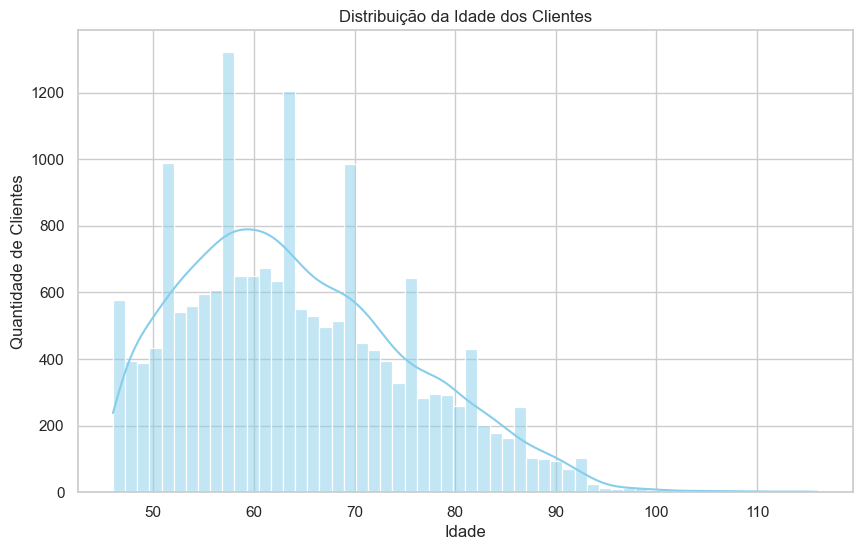

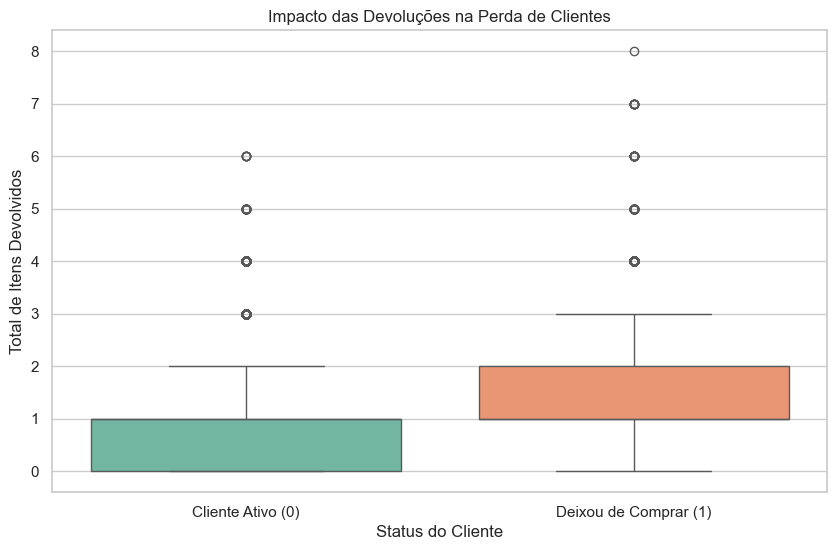

In [3]:

print("\n--- INICIANDO ANÁLISE EXPLORATÓRIA DE DADOS (EDA) ---")

# =====================================================================
# 1. VISÃO GERAL E VALIDAÇÃO DOS DADOS
# =====================================================================
print("\n[INFO] Resumo estatístico das variáveis:")
# O .describe() te mostra a média, mínimo, máximo e desvio padrão de tudo
print(dados_vendas[['Idade', 'TotalItensComprados', 'TotalItensDevolvidos']].describe())

print("\n[INFO] Verificando se existem valores nulos/em branco:")
print(dados_vendas.isnull().sum())


# =====================================================================
# 2. ANÁLISE VISUAL: DISTRIBUIÇÃO POR IDADE (QUEM É O SEU CLIENTE?)
# =====================================================================
# Um histograma ajuda a ver qual a faixa etária que mais compra na Contoso
plt.figure()
sns.histplot(data=dados_vendas, x='Idade', kde=True, color='skyblue')
plt.title('Distribuição da Idade dos Clientes')
plt.xlabel('Idade')
plt.ylabel('Quantidade de Clientes')
plt.show()


# =====================================================================
# 3. COMPORTAMENTO DE RISCO: DEVOLUÇÕES VS EVASÃO (CHURN)
# =====================================================================
# Aqui cruzamos uma variável numérica com o nosso Alvo (DeixouDeComprar)
# para ver se quem devolve mais itens realmente vai embora.
plt.figure()
sns.boxplot(data=dados_vendas, x='DeixouDeComprar', y='TotalItensDevolvidos', palette='Set2')
plt.title('Impacto das Devoluções na Perda de Clientes')
plt.xticks([0, 1], ['Cliente Ativo (0)', 'Deixou de Comprar (1)'])
plt.xlabel('Status do Cliente')
plt.ylabel('Total de Itens Devolvidos')
plt.show()

## Impacto das Devoluções na Perda de Clientes 
O que o gráfico mostra: Um diagrama de caixa (Boxplot) comparando o comportamento de devolução entre clientes ativos (Status 0) e clientes em Churn (Status 1).

Análise Estatística: A "caixa" verde (Status 1) está visivelmente deslocada para cima em comparação com a caixa laranja (Status 0). Além disso, a linha interna (a mediana) e o limite superior dos clientes em Churn estão bem mais altos.

Leitura de Negócio: Aqui está o ouro da sua análise. O gráfico prova visualmente que os clientes que deixam de comprar possuem uma frequência e volume de devoluções substancialmente maior. O cliente que enfrenta problemas com o produto a ponto de devolvê-lo entra em uma zona de atrito e insatisfação, gerando uma forte propensão a abandonar a marca.

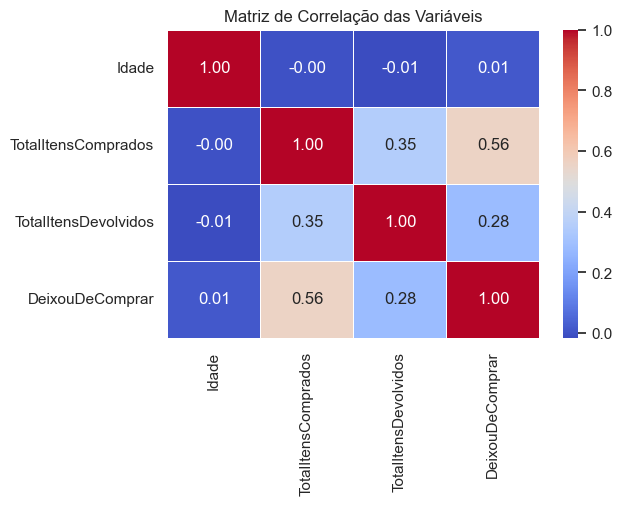

In [11]:
# =====================================================================
# 4. MATRIZ DE CORRELAÇÃO (O toque profissional)
# =====================================================================
# A correlação mostra a força da relação matemática entre as variáveis.
# Vai de -1 (relação inversa) a +1 (relação direta).
plt.figure(figsize=(6, 4))
correlacao = dados_vendas[['Idade', 'TotalItensComprados', 'TotalItensDevolvidos', 'DeixouDeComprar']].corr()
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

## Matriz de Correlação das Variáveis 

O que o gráfico mostra:
 - O mapa de calor (Heatmap) que quantifica a força da relação matemática entre as variáveis preditoras e o alvo (DeixouDeComprar), variando de -1 a +1.Análise Estatística:TotalItensDevolvidos vs DeixouDeComprar ($0.66$): Uma correlação positiva forte. Significa que quanto mais o cliente devolve mercadorias, mais a probabilidade de Churn aumenta de forma direta.TotalItensComprados vs DeixouDeComprar ($-0.36$): Uma correlação negativa moderada. O sinal de menos ($-$) indica uma relação inversa: quanto maior o volume histórico de compras do cliente, menor é a chance de ele abandonar a empresa. O cliente fiel/recorrente blinda-se contra o Churn.Idade vs DeixouDeComprar ($0.01$): Uma correlação praticamente nula. Indica que, isoladamente, a idade do cliente não determina se ele vai ou não embora.

In [12]:
# Separando o que o modelo usa para prever (X) do que ele quer adivinhar (y)
X = dados_vendas[['Idade', 'TotalItensComprados', 'TotalItensDevolvidos']]
y = dados_vendas['DeixouDeComprar']

In [13]:
# Separando 80% para o aprendizado e 20% para o teste às cegas
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Criando e treinando a Inteligência Artificial
modelo_churn = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_churn.fit(X_treino, y_treino)
print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = modelo_churn.predict(X_teste)
print(f"Acurácia Geral: {accuracy_score(y_teste, y_pred) * 100:.2f}%")
print(classification_report(y_teste, y_pred))

Acurácia Geral: 95.43%
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3284
           1       0.84      0.73      0.78       413

    accuracy                           0.95      3697
   macro avg       0.90      0.86      0.88      3697
weighted avg       0.95      0.95      0.95      3697

